In [1]:
import re
import numpy as np
import xarray as xr
import pandas as pd
from flights_io  import get_matched_flights
from flight_processing import process_flight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

In [2]:
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [3]:
results = []

for flight in flights:
    out = process_flight(flight)

    # First find common times between neph and AMS
    #common_times = np.intersect1d(out.neph_resampled_time, out.ams_resampled_time)
    #print(out.ams.time.values)
    # Then intersect with AMS and core
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    sp2_resampled_matched = out.sp2.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)
    Dg_aligned_matched = out.Dgs.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = out.PM_ratio.sel(PCAS2TSPM = common_times)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    AS = ams_resampled_matched['NH4_2SO4'].values
    AN = ams_resampled_matched['NH4NO3'].values
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', flight.core)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number
    })

In [36]:
# Combine all flight data
combined_data = []
for entry in results:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'rBC': entry['BC'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'OA': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

In [25]:
scattering_vars = ['TSC_green']
absorption_vars = ['ABS_PSAP']
chemistry_vars = ['rBC', 'SO4', 'NH4', 'NO3', 'OA']
other_vars = ['CO']

In [26]:
def summarize_optical(
    df,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
):
    """
    Compute summary statistics with:
    - scaling for optical variables (Mm^-1)
    - unit-aware output
    - total mass from chemistry
    """

    summary = []

    # --- Compute total mass ---
    df = df.copy()
    df["Total_mass"] = df[chemistry_vars].sum(axis=1)

    # --- Variable groups ---
    all_vars = (
        [(v, "scattering") for v in scattering_vars] +
        [(v, "absorption") for v in absorption_vars] +
        [(v, "other") for v in other_vars] +
        [("Total_mass", "mass")]
    )

    for var, vtype in all_vars:
        data = df[var].dropna()

        # --- Apply scaling ---
        if vtype in ["scattering", "absorption"]:
            data = data * 1e6
            unit = "Mm⁻¹"
        elif var == "CO":
            unit = "ppb"
        elif var == "Total_mass":
            unit = "µg m⁻³"  # adjust if needed
        else:
            unit = "-"

        summary.append({
            "variable": var,
            "type": vtype,
            "mean": data.mean(),
            "std": data.std(),
            "min": data.min(),
            "max": data.max(),
            "N": data.count(),
            "unit": unit
        })

    return pd.DataFrame(summary)

In [27]:
def summarize_chemistry_fraction(df, chemistry_vars):
    """
    Compute relative (%) contribution of each species.
    """

    # Total mass (row-wise)
    total_mass = df[chemistry_vars].sum(axis=1)

    # Avoid division by zero
    total_mass = total_mass.replace(0, np.nan)

    # Fraction per species
    fractions = df[chemistry_vars].div(total_mass, axis=0) * 100

    summary = []

    for var in chemistry_vars:
        data = fractions[var].dropna()

        summary.append({
            "variable": var,
            "mean_pct": data.mean(),
            "std_pct": data.std(),
            "min_pct": data.min(),
            "max_pct": data.max(),
            "N": data.count()
        })

    return pd.DataFrame(summary)

In [38]:
def build_summary(
    df,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
):

    optical_summary = summarize_optical(
        df,
        scattering_vars,
        absorption_vars,
        other_vars,
        chemistry_vars
    )

    optical_summary["category"] = "optical"

    chem_summary = summarize_chemistry_fraction(df, chemistry_vars)
    chem_summary["category"] = "chemistry"

    return optical_summary, chem_summary

In [39]:
optical_all, chem_all = build_summary(
    df_clean,
    scattering_vars,
    absorption_vars,
    other_vars,
    chemistry_vars
)

In [40]:
optical_all
#chem_all

,variable,type,mean,std,min,max,N,unit,category
0,TSC_green,scattering,65.965302,72.986968,-0.006383,917.333333,776,Mm⁻¹,optical
1,ABS_PSAP,absorption,14.006824,10.979097,0.224515,52.752419,776,Mm⁻¹,optical
2,CO,other,251.578079,140.394379,91.536819,1250.996704,776,ppb,optical
3,Total_mass,mass,12.536315,18.024416,0.686689,246.655374,776,µg m⁻³,optical


In [41]:
flight_summaries = {}
for flight_id, df_flight in df_clean.groupby("Flight"):
    optical, chem = build_summary(
        df_flight,
        scattering_vars,
        absorption_vars,
        other_vars,
        chemistry_vars
    )

    flight_summaries[flight_id] = {
        "optical": optical,
        "chemistry": chem
    }

In [42]:
flight_summaries["b737"]

{'optical':      variable        type        mean         std         min          max  \
 0   TSC_green  scattering  121.059562  180.595280    8.926950   917.333333   
 1    ABS_PSAP  absorption   16.211885   12.031940    0.500293    52.736332   
 2          CO       other  295.633575  242.323761  140.024368  1250.996704   
 3  Total_mass        mass   29.912691   48.392852    4.068569   246.655374   
 
     N    unit category  
 0  68    Mm⁻¹  optical  
 1  68    Mm⁻¹  optical  
 2  68     ppb  optical  
 3  68  µg m⁻³  optical  ,
 'chemistry':   variable   mean_pct   std_pct    min_pct    max_pct   N   category
 0      rBC   2.232107  2.476863   0.076885  10.035555  68  chemistry
 1      SO4   8.225241  2.825641   0.976285  14.367972  68  chemistry
 2      NH4   4.188592  1.689892   0.834205   8.331332  68  chemistry
 3      NO3   3.304185  1.560987   1.027639   9.418108  68  chemistry
 4       OA  82.049876  4.747495  69.170533  96.299187  68  chemistry}

In [43]:
def plot_summary(optical_df, chem_df, title="Summary"):

    fig = plt.figure(figsize=(13, 6))

    # =========================
    # TABLE
    # =========================
    ax_table = fig.add_subplot(1, 2, 1)
    ax_table.axis("off")

    col_labels = ["Var", "Mean ± Std", "Min", "Max", "N", "Unit"]

    table_data = []

    for _, row in optical_df.iterrows():
        table_data.append([
            row["variable"],
            f"{row['mean']:.2f} ± {row['std']:.2f}",
            f"{row['min']:.2f}",
            f"{row['max']:.2f}",
            int(row["N"]),
            row["unit"]
        ])

    table = ax_table.table(
        cellText=table_data,
        colLabels=col_labels,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.3)

    ax_table.set_title("Optical, CO, and Mass Summary", fontsize=12)

    # =========================
    # PIE CHART
    # =========================
    ax_pie = fig.add_subplot(1, 2, 2)

    chem_df_clean = chem_df.dropna(subset=["mean_pct"])

    chem_df_clean = chem_df_clean.sort_values("mean_pct", ascending=False)

    ax_pie.pie(
        chem_df_clean["mean_pct"],
        labels=chem_df_clean["variable"],
        autopct="%1.1f%%"
    )

    ax_pie.set_title("Chemical Composition (%)", fontsize=12)

    # =========================
    # TITLE
    # =========================
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

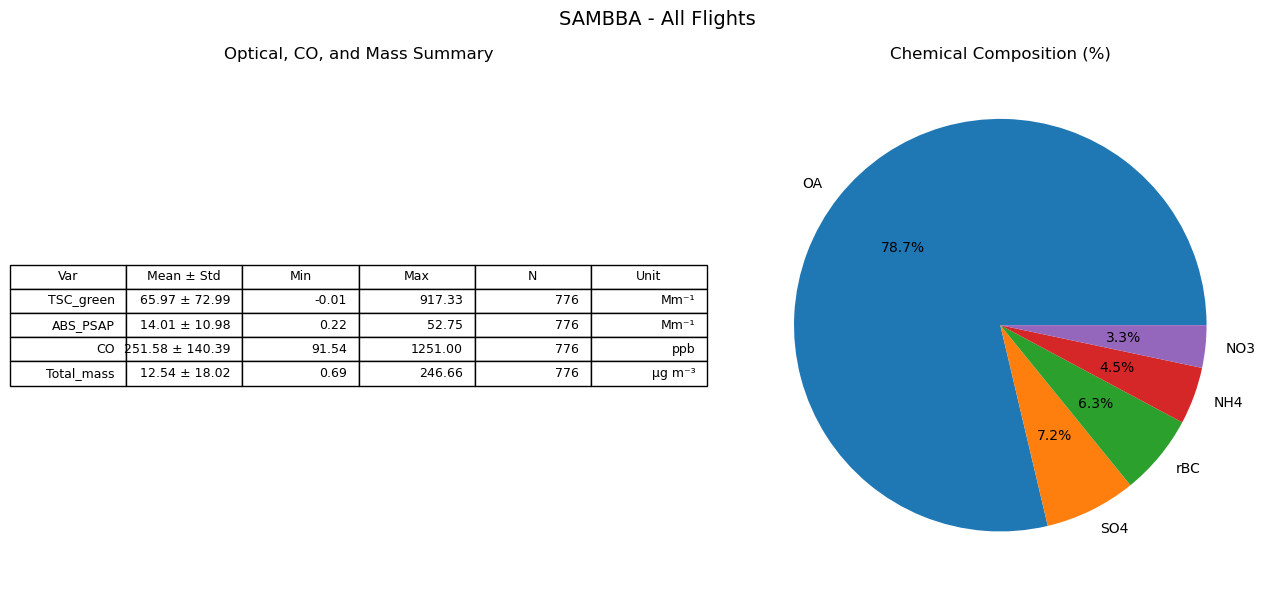

In [44]:
plot_summary(
    optical_all,
    chem_all,
    title="SAMBBA - All Flights"
)

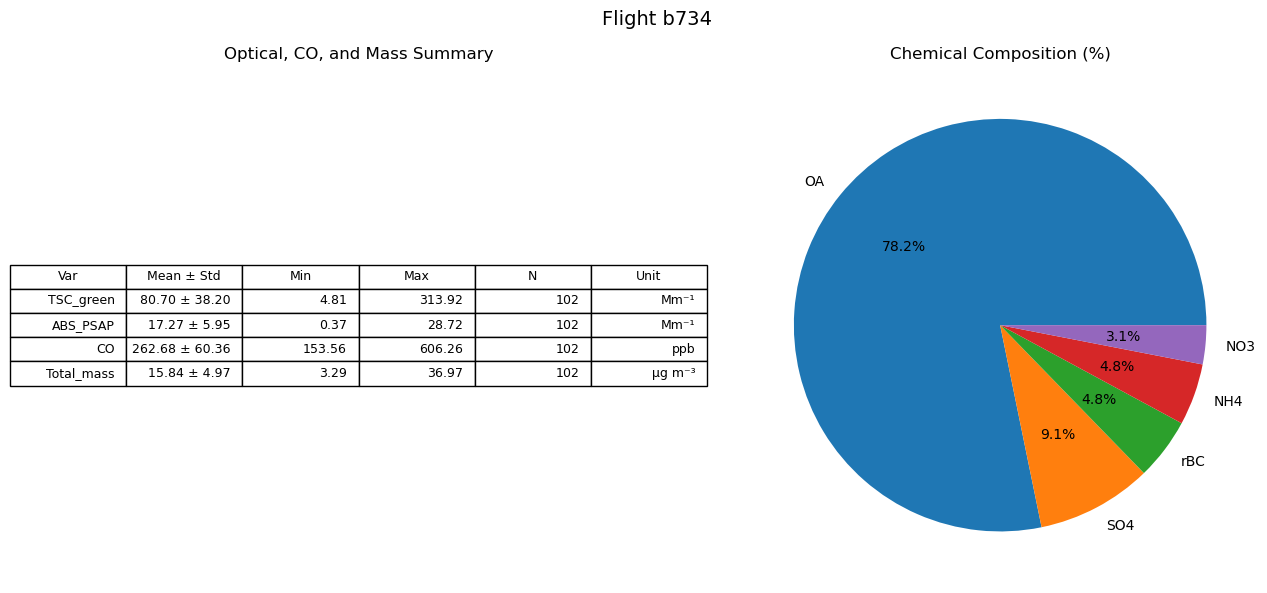

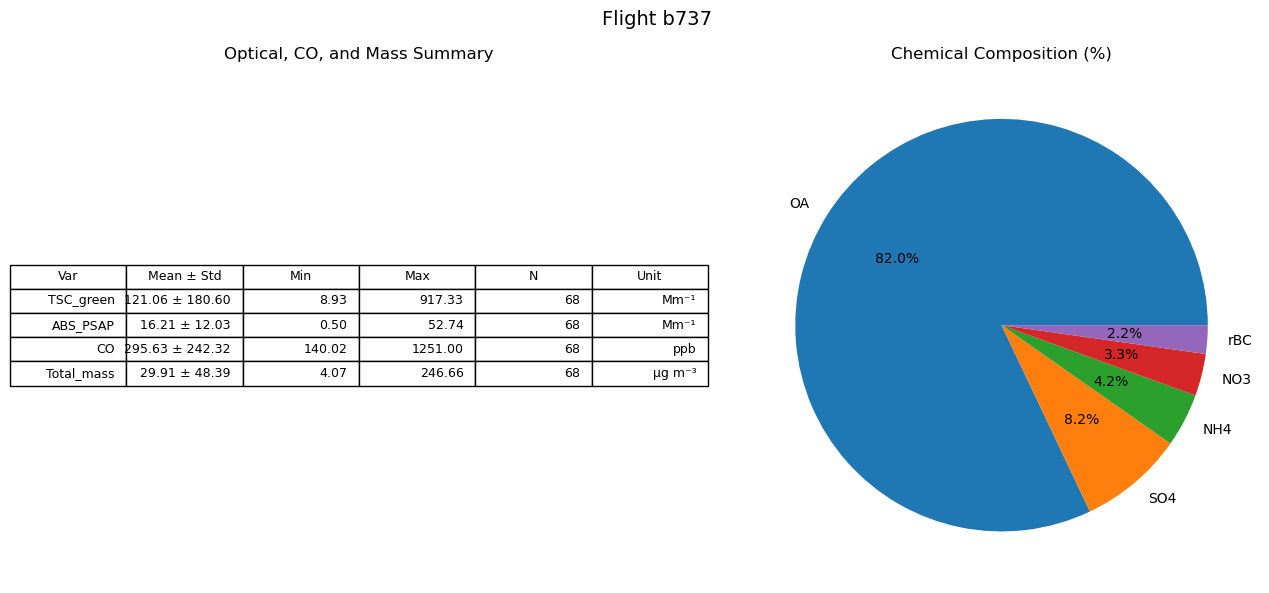

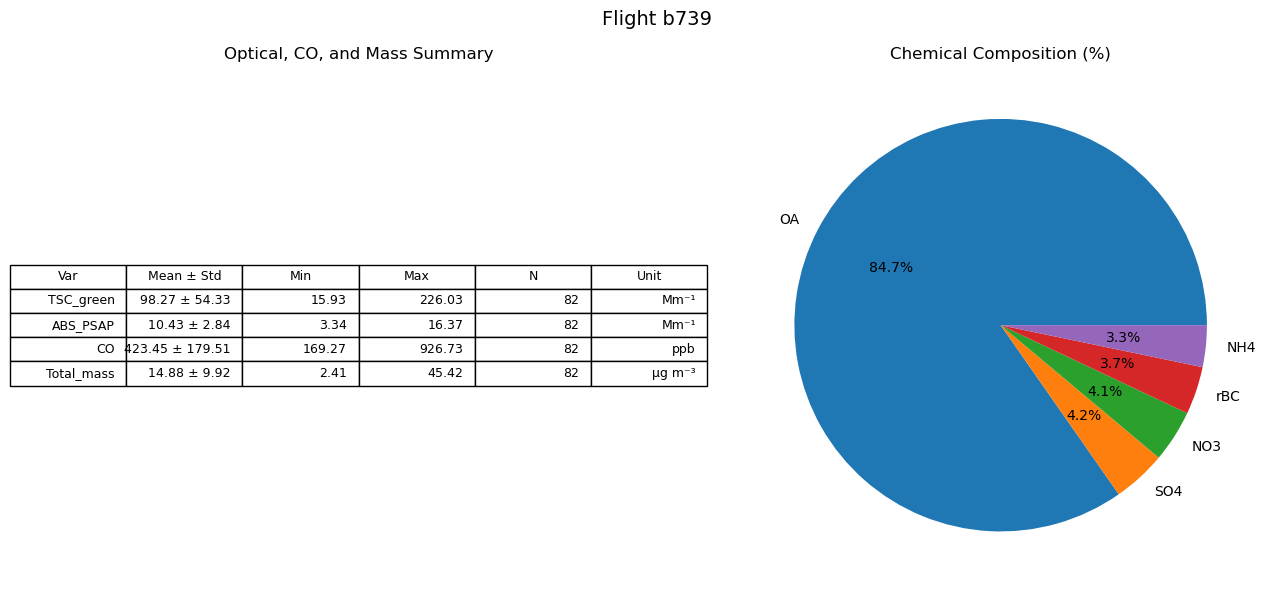

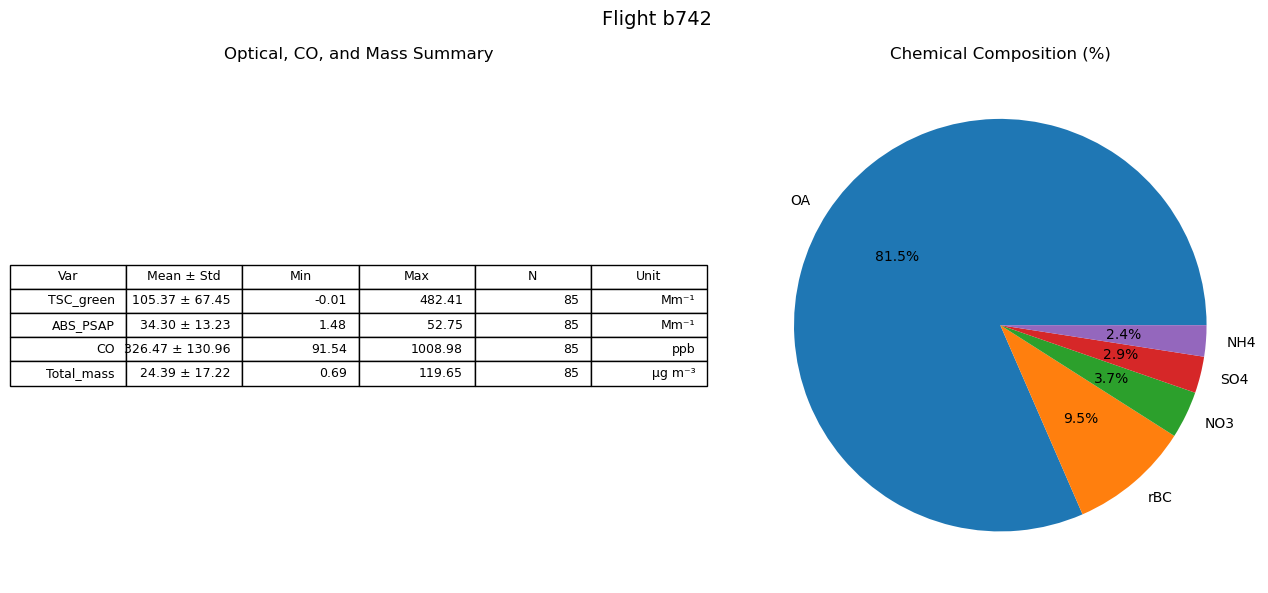

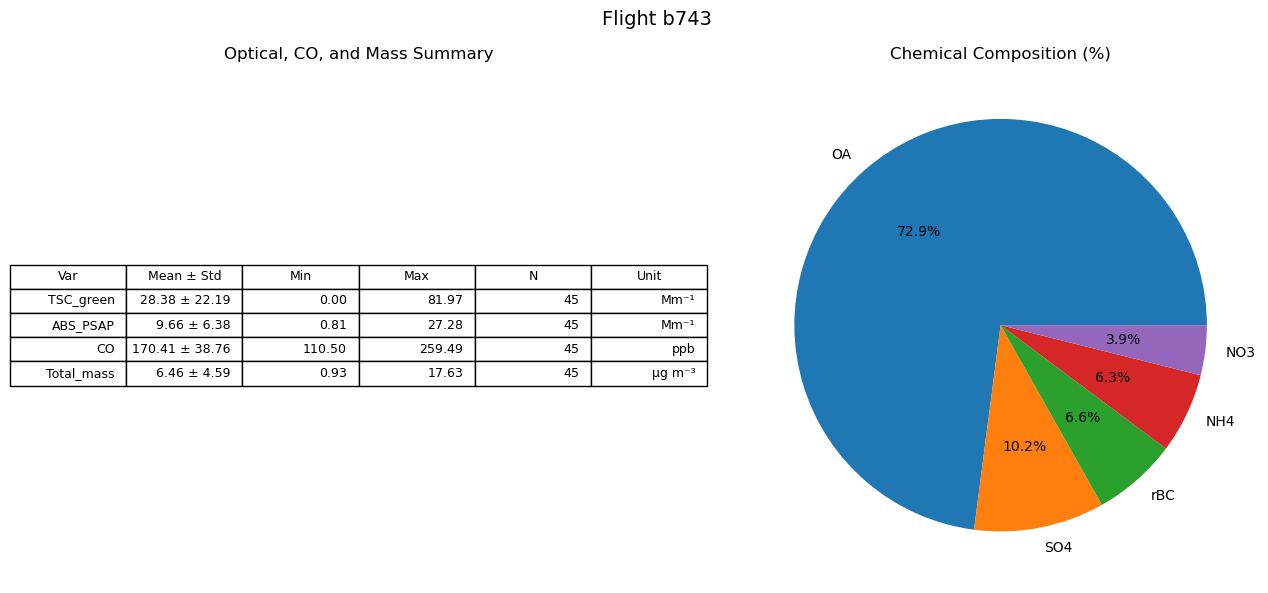

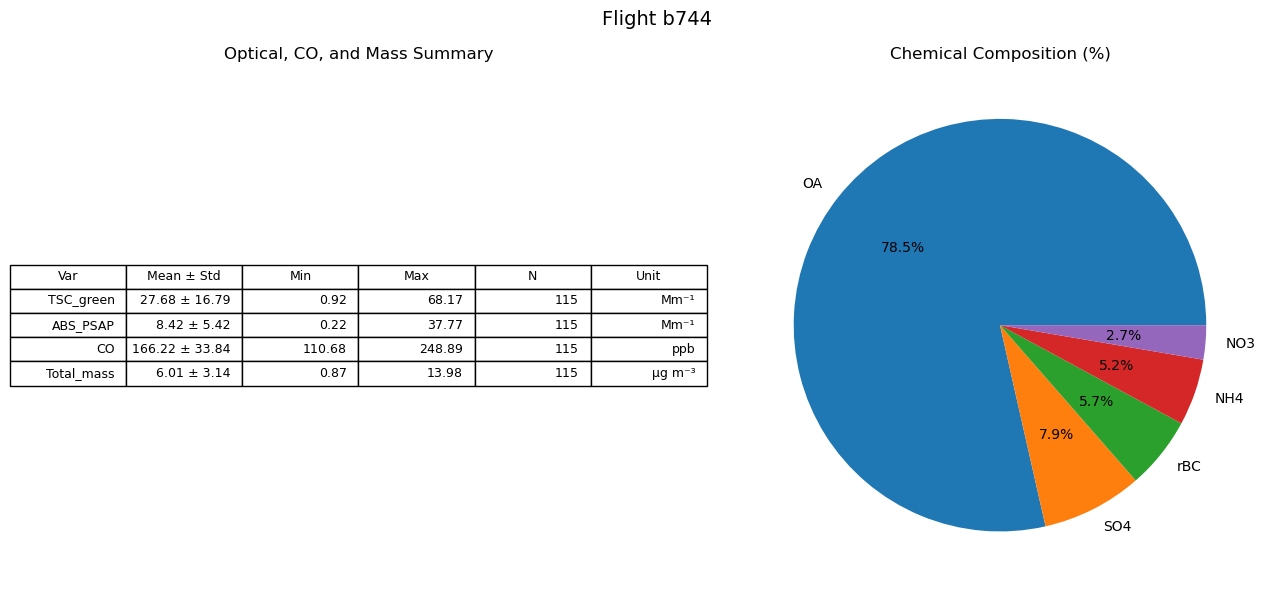

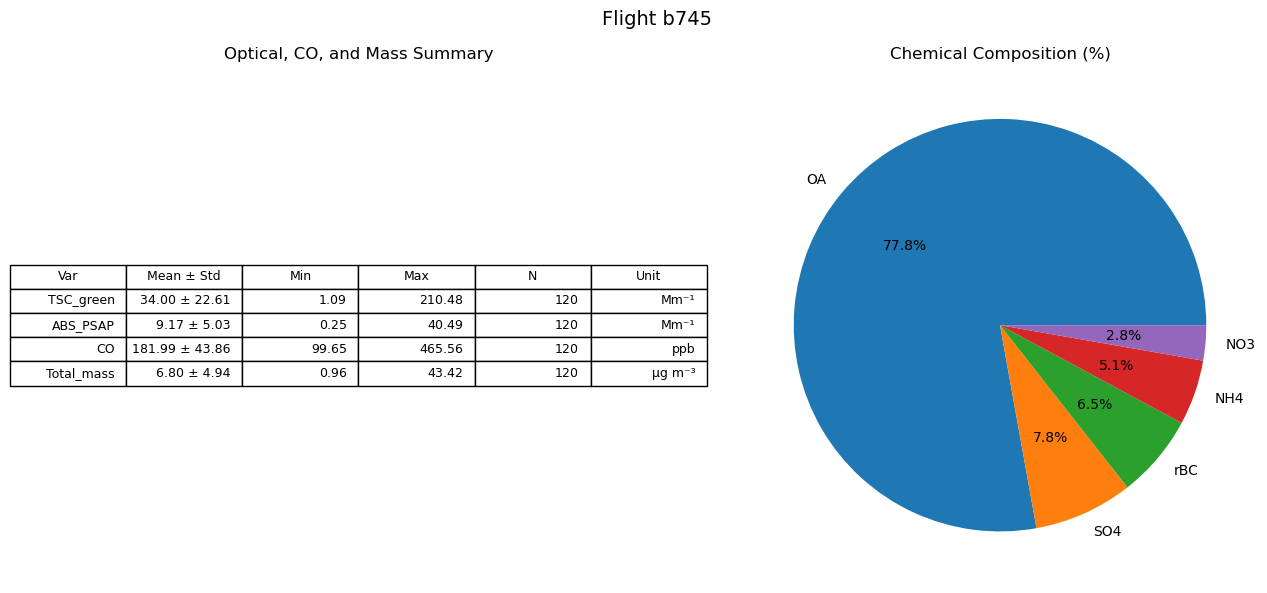

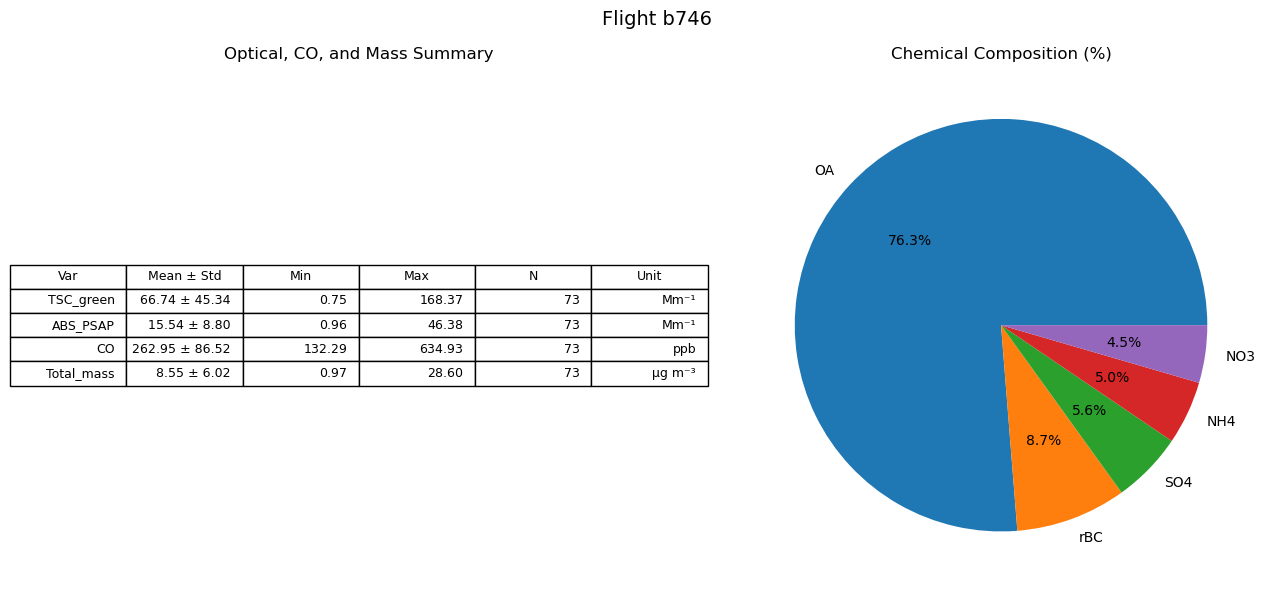

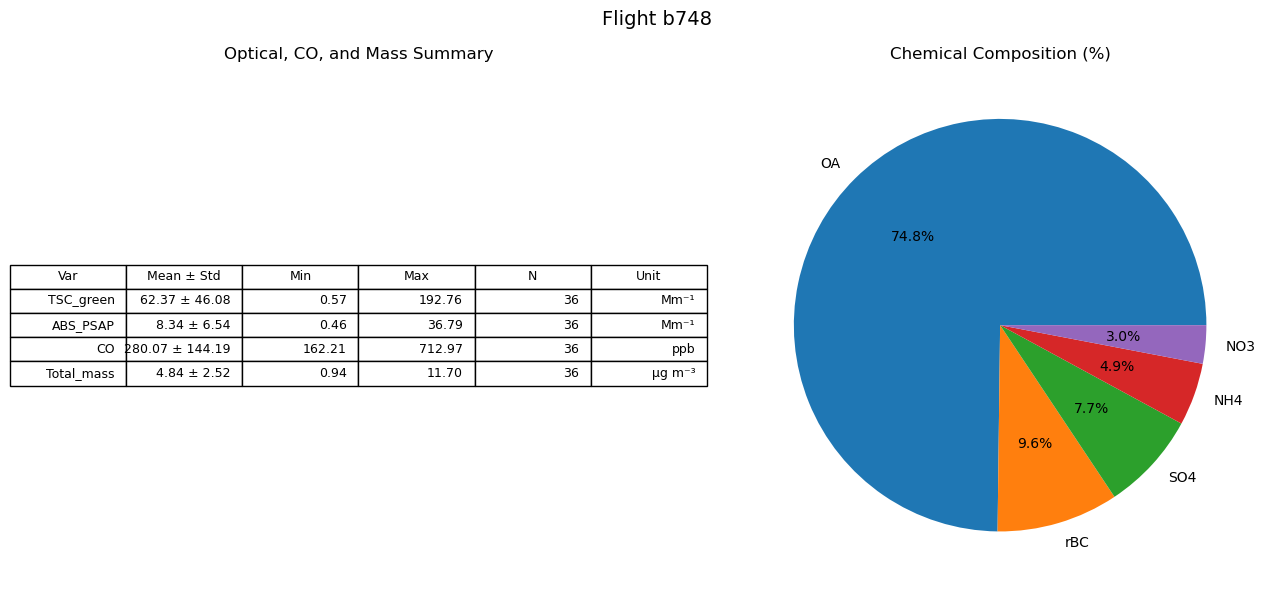

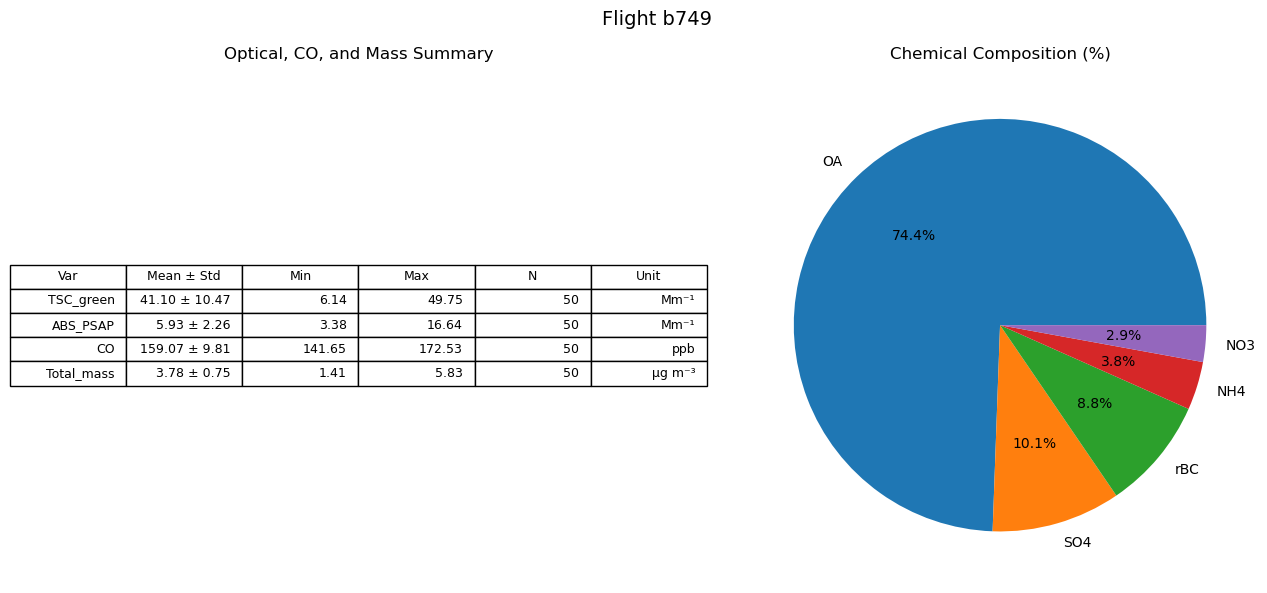

In [45]:
for flight_id, data in flight_summaries.items():

    plot_summary(
        data["optical"],
        data["chemistry"],
        title=f"Flight {flight_id}"
    )